<a href="https://colab.research.google.com/github/Projeto-MLG/Simulacao-de-Opiniao-Publica/blob/main/Projeto_MLG_Opini%C3%A3o_P%C3%BAblica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Instalações e Importações

In [ ]:

# 1. INSTALAR DEPENDÊNCIA PARA LEITURA .SAV
!pip install pyreadstat==1.2.6 --quiet  # instala a biblioteca necessária para o pandas ler arquivos SPSS (.sav)
!pip install gdown --quiet

# 2. IMPORTAÇÕES
import pandas as pd
import os
import requests
import gdown
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from scipy.spatial.distance import jensenshannon

warnings.filterwarnings("ignore", category=FutureWarning)  # oculta avisos do tipo FutureWarning para deixar a saída mais limpa


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 19.8 MB/s eta 0:00:00


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# 1. DEFINIR MODELOS ADICIONAIS
# Nesta etapa, foram definidos modelos adicionais para comparação, com parâmetros padrão ou ajustados minimamente.

# Já temos 'modelo_rf' definido na Etapa 2.
modelo_gbm = GradientBoostingClassifier(n_estimators=150, learning_rate=0.15, max_depth=4, random_state=42)
modelo_nn = MLPClassifier(hidden_layer_sizes=(120, 60), max_iter=300, activation='relu', solver='adam', random_state=42, early_stopping=True, validation_fraction=0.1)
modelo_knn = KNeighborsClassifier(n_neighbors=7)

In [ ]:
# 2. FUNÇÃO PARA AVALIAÇÃO DE MODELOS COM VALIDAÇÃO CRUZADA
# Esta função realiza a validação cruzada estratificada (K-Fold) para um dado modelo e retorna a acurácia média e o desvio padrão.
# Ela reutiliza o 'preprocessador' já definido na Etapa 2 (célula Q92n0OXO8Xyt) que exclui 'id_respondente'.

def evaluate_model_cv(model, X_train_data, y_train_data, preprocessador, target_names, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    accuracies = []
    print(f"\nRealizando validação cruzada para {model.__class__.__name__} com {n_splits} folds...")

    for fold, (train_index, val_index) in enumerate(skf.split(X_train_data, y_train_data)):
        X_train_fold, X_val_fold = X_train_data.iloc[train_index], X_train_data.iloc[val_index]
        y_train_fold, y_val_fold = y_train_data[train_index], y_train_data[val_index]

        # Criar um pipeline específico para esta avaliação, usando o preprocessador existente
        model_pipeline = Pipeline(steps=[
            ("preprocessamento", preprocessador),
            ("modelo", model)
        ])

        model_pipeline.fit(X_train_fold, y_train_fold)
        y_pred_fold = model_pipeline.predict(X_val_fold)
        fold_acc = accuracy_score(y_val_fold, y_pred_fold)
        accuracies.append(fold_acc)
        print(f"Acurácia do Fold {fold + 1}: {fold_acc:.4f}")

    mean_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)
    print(f"Acurácia Média: {mean_accuracy:.4f} (+/- {std_accuracy:.4f})")
    return mean_accuracy, std_accuracy

In [ ]:
# 3. AVALIAR TODOS OS MODELOS E COLETAR RESULTADOS
# Nesta etapa, cada modelo será avaliado usando a função de validação cruzada.
# 'X_temp_train_features' e 'y_temp_train' (dados de treino para CV) já estão definidos na Etapa 2.
# 'preprocessador' também já está definido na Etapa 2 (célula Q92n0OXO8Xyt).

models = {
    "Random Forest": modelo_rf,
    "Gradient Boosting Machine (GBM)": modelo_gbm,
    "Neural Network (MLP)": modelo_nn,
    "K-Nearest Neighbors (KNN)"
: modelo_knn
}

results = []

for name, model in models.items():
    print(f"\n--- Avaliando: {name} ---")
    avg_acc, std_acc = evaluate_model_cv(model, X_temp_train_features, y_temp_train, preprocessador, le_y.classes_)
    results.append({
        "Modelo": name,
        "Acurácia Média (CV)": avg_acc,
        "Desvio Padrão (CV)": std_acc
    })

df_results_comparativo = pd.DataFrame(results)
df_results_comparativo_sorted = df_results_comparativo.sort_values(by="Acurácia Média (CV)", ascending=False)


--- Avaliando: Random Forest ---

Realizando validação cruzada para RandomForestClassifier com 5 folds...
Acurácia do Fold 1: 0.3750
Acurácia do Fold 2: 0.4111
Acurácia do Fold 3: 0.3778
Acurácia do Fold 4: 0.4278
Acurácia do Fold 5: 0.4000
Acurácia Média: 0.3983 (+/- 0.0200)

--- Avaliando: Gradient Boosting Machine (GBM) ---

Realizando validação cruzada para GradientBoostingClassifier com 5 folds...
Acurácia do Fold 1: 0.3306
Acurácia do Fold 2: 0.3361
Acurácia do Fold 3: 0.2917
Acurácia do Fold 4: 0.3944
Acurácia do Fold 5: 0.3444
Acurácia Média: 0.3394 (+/- 0.0329)

--- Avaliando: Neural Network (MLP) ---

Realizando validação cruzada para MLPClassifier com 5 folds...
Acurácia do Fold 1: 0.3556
Acurácia do Fold 2: 0.3611
Acurácia do Fold 3: 0.3667
Acurácia do Fold 4: 0.4000
Acurácia do Fold 5: 0.3972
Acurácia Média: 0.3761 (+/- 0.0187)

--- Avaliando: K-Nearest Neighbors (KNN) ---

Realizando validação cruzada para KNeighborsClassifier com 5 folds...
Acurácia do Fold 1: 0.3056
Ac

In [ ]:
# 4. EXIBIR COMPARAÇÃO DE ACURÁCIA DOS MODELOS
# Esta etapa exibe a acurácia média de cada modelo em um formato de tabela para fácil comparação.
print("\n--- Comparação de Acurácia dos Modelos Supervisionados (Validação Cruzada) ---")
display(df_results_comparativo_sorted)


--- Comparação de Acurácia dos Modelos Supervisionados (Validação Cruzada) ---


,Modelo,Acurácia Média (CV),Desvio Padrão (CV)
0,Random Forest,0.398333,0.020000
2,Neural Network (MLP),0.376111,0.018725
1,Gradient Boosting Machine (GBM),0.339444,0.032933
3,K-Nearest Neighbors (KNN),0.325556,0.016796


#Etapa 1 - Preparação dos Dados

In [ ]:
# 1. CONFIGURAÇÃO DO DOWNLOAD

file_id = "1iHHbN41K3ixLJdus8-hWt1uRE5b3o2T0"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
output = "Base_Desigualdade.sav" # define o nome do arquivo local


# 2. FUNÇÕES AUXILIARES DE DOWNLOAD
# Nesta etapa, são definidas funções auxiliares para verificar a validade de um arquivo (se existe e tem tamanho mínimo)

def arquivo_valido(caminho):
    return os.path.exists(caminho) and os.path.getsize(caminho) > 1024

def download_google_drive(url, output):
    session = requests.Session()
    response = session.get(url, stream=True)

    for key, value in response.cookies.items():
        if key.startswith("download_warning"):
            response = session.get(url + "&confirm=" + value, stream=True)
            break

    with open(output, "wb") as f:
        for chunk in response.iter_content(32768):
            if chunk:
                f.write(chunk)



# 3. BAIXAR O ARQUIVO APENAS SE NECESSÁRIO
# Nesta etapa, o sistema garante que o arquivo de dados Base_Desigualdade.sav esteja disponível,
# baixando-o do Google Drive apenas se ele não existir ou estiver inválido, ou forçando um novo download.

if os.path.exists(output):
    os.remove(output)

if not arquivo_valido(output):
    print("Baixando arquivo...")
    download_google_drive(url, output)
else:
  print("Arquivo já existe e é válido — download ignorado.") # informa que o download foi pulado

# 4. LEITURA DO ARQUIVO .SAV
# Nesta etapa, o código lê o arquivo Base_Desigualdade.sav para um DataFrame do pandas e, salva o DataFrame
# completo em um arquivo CSV chamado Base_Desigualdade_raw.csv

df = pd.read_spss(output)

# Criar id_respondente antes de qualquer filtro ou alteração
df.reset_index(drop=True, inplace=True)
df["id_respondente"] = df.index

print("Dimensão da base original:")
display(df.shape)

print("\nPrimeiras linhas da base original:")
display(df.head())

df.to_csv("Base_Desigualdade_raw.csv", index=False)


# 5. SELEÇÃO DAS VARIÁVEIS DE INTERESSE
# Nesta etapa, foi definido as variáveis com foco em desigualdade

colunas_interesse = [
    "SEXO",
    "ESCOLARIDADE",
    "IDADE",
    "RACA_COR",
    "RELIGIÃO",
    "REND1",
    "REND2",
    "REGIAO",
    "COND",
    "PORTE",
    "P5_1",
  ]


# 6. FUNÇÃO DE MAPEAMENTO FLEXÍVEL
# Nesta etapa, criamos uma função para traduzir os números das colunas em palavras que entendemos, mas só fazemos
# isso se a coluna for de números; se já for de palavras, deixamos como está

def aplicar_mapeamento(coluna, mapa):
    if pd.api.types.is_numeric_dtype(coluna):
        coluna = pd.to_numeric(coluna, errors="coerce").astype("Int64")
        return coluna.map(mapa)
    else:
        return coluna


# 7. DICIONÁRIOS DE TRADUÇÃO
# Nesta etapa, são criados vários dicionários de tradução que mapeiam códigos numéricos para descrições textuais,
# preparando as colunas para serem mais compreensíveis.

map_sexo = {  # define dicionário de sexo
    1: "Masculino",  # código 1
    2: "Feminino"  # código 2
}

map_escolaridade = {  # define dicionário de escolaridade (É feito o agrupamento das séries)
    1: "Baixa escolaridade",  # analfabeto
    2: "Baixa escolaridade",  # sabe ler/escrever sem escola
    3: "Fundamental",  # pré-escola
    4: "Fundamental",  # 1ª série
    5: "Fundamental",  # 2ª série
    6: "Fundamental",  # 3ª série
    7: "Fundamental",  # 4ª série
    8: "Fundamental",  # 5ª série
    9: "Fundamental",  # 6ª série
    10: "Fundamental",  # 7ª série
    11: "Fundamental",  # 8ª série
    12: "Médio",  # 1ª série do médio
    13: "Médio",  # 2ª série do médio
    14: "Médio",  # 3ª série do médio
    15: "Superior",  # superior incompleto
    16: "Superior"  # superior completo
}

map_raca = {  # define dicionário de raça/cor
    1: "Branca",  # código 1
    2: "Preta",  # código 2
    3: "Parda",  # código 3
    4: "Amarela",  # código 4
    5: "Indígena"  # código 5
}

map_rend = {  # define dicionário de renda
    1: "Mais de 20 SM",  # faixa mais alta
    2: "Mais de 10 a 20 SM",  # faixa alta
    3: "Mais de 5 a 10 SM",  # faixa média-alta
    4: "Mais de 2 a 5 SM",  # faixa média
    5: "Mais de 1 a 2 SM",  # faixa média-baixa
    6: "Até 1 SM",  # faixa baixa
    98: "Sem rendimento",  # sem rendimento
    99: "Não respondeu"  # sem resposta
}

map_regiao = {  # define dicionário de região
    1: "Norte",  # código 1
    2: "Nordeste",  # código 2
    3: "Sudeste",  # código 3
    4: "Sul",  # código 4
    5: "Centro-Oeste"  # código 5
}

map_cond = {  # define dicionário da condição do município
    1: "Capital",  # código 1
    2: "Periferia",  # código 2
    3: "Interior"  # código 3
}

map_porte = {  # define dicionário do porte do município
    1: "Até 5 mil",  # código 1
    2: "5 a 10 mil",  # código 2
    3: "10 a 20 mil",  # código 3
    4: "20 a 50 mil",  # código 4
    5: "50 a 100 mil",  # código 5
    6: "100 a 500 mil",  # código 6
    7: "Mais de 500 mil"  # código 7
}

map_p5 = {  # define dicionário da percepção de aumento de pobreza/fome
    1: "Dificuldade para comprar alimentos",  # código 1
    2: "Mais pessoas nos semáforos/ruas",  # código 2
    3: "Mais favelas/barracos/áreas ocupadas",  # código 3
    4: "Aumento da população em situação de rua",  # código 4
    97: "Não percebeu aumento",  # não percebeu
    98: "Não sabe",  # não sabe
    99: "Não respondeu"  # sem resposta
}

# 8. CRIAR COLUNAS DESCRITIVAS (TEXTO CONTINUA TEXTO)
# Nesta etapa, é criado novas colunas com nomes fáceis de entender para as características dos dados

df["sexo_desc"] = aplicar_mapeamento(df["SEXO"], map_sexo)
df["escolaridade_desc"] = aplicar_mapeamento(df["ESCOLARIDADE"], map_escolaridade)
df["idade_num"] = pd.to_numeric(df["IDADE"], errors="coerce")
df["raca_desc"] = aplicar_mapeamento(df["RACA_COR"], map_raca)
df["religiao_desc"] = df["RELIGIÃO"]
df["rend1_desc"] = aplicar_mapeamento(df["REND1"], map_rend)
df["rend2_desc"] = aplicar_mapeamento(df["REND2"], map_rend)
df["regiao_desc"] = aplicar_mapeamento(df["REGIAO"], map_regiao)
df["cond_desc"] = aplicar_mapeamento(df["COND"], map_cond)
df["porte_desc"] = aplicar_mapeamento(df["PORTE"], map_porte)
df["p5_desc"] = aplicar_mapeamento(df["P5_1"], map_p5) # p5_desc é a variável alvo


# 9. DEFINIR COLUNAS TEXTUAIS E NUMÉRICAS
# Nesta etapa, é feito a organização das colunas em duas listas: uma para as colunas
# que contêm texto e outra para as colunas que contêm números.
# A variável alvo p5_desc não é incluída aqui, pois ela é a *váriavel alvo*

colunas_texto = [
    "sexo_desc",
    "escolaridade_desc",
    "raca_desc",
    "religiao_desc",
    "rend1_desc",
    "rend2_desc",
    "regiao_desc",
    "cond_desc",
    "porte_desc",
]

colunas_numericas = [
    "idade_num"
]

# 12. PREENCHIMENTO LÓGICO DE FALTANTES
# Nesta etapa, Este é preenchido os dados que estão faltando nas colunas com 'Não informado'

for col in colunas_texto:
    if isinstance(df[col].dtype, pd.CategoricalDtype):
        if 'Não informado' not in df[col].cat.categories:
            df[col] = df[col].cat.add_categories('Não informado')
    df[col] = df[col].fillna("Não informado")

for col in colunas_numericas:
    mediana_coluna = df[col].median()
    df[col] = df[col].fillna(mediana_coluna)


# 13. NORMALIZAÇÃO APENAS DAS COLUNAS NUMÉRICAS
# Nesta etapa é feito a normalização da escala das colunas numéricas, transformando seus valores para que fiquem entre 0 e 1.

scaler = MinMaxScaler()

df[[f"{col}_norm" for col in colunas_numericas]] = scaler.fit_transform(df[colunas_numericas])


# 14. CRIAÇÃO DO DATASET FINAL DA ETAPA 1
# Nesta etapa, é selecionado as colunas 'importantes' e criado o dataset final que será usado para o modelo supervisionado.

colunas_finais = [
    "id_respondente", # Adicionado id_respondente
    "sexo_desc",  # sexo descritivo
    "escolaridade_desc",  # escolaridade descritiva
    "raca_desc",  # raça/cor descritiva
    "religiao_desc",  # religião descritiva
    "rend1_desc",  # renda pessoal descritiva
    "rend2_desc",  # renda familiar descritiva
    "regiao_desc",  # região descritiva
    "cond_desc",  # condição do município descritiva
    "porte_desc",  # porte do município descritiva
    "idade_num",  # idade numérica original tratada
    "idade_num_norm",  # idade normalizada
    "p5_desc"  # variável alvo final
]

df_modelo = df[colunas_finais].copy()

df_modelo.to_csv("df_modelo_preparado_etapa1.csv", index=False)

print("\nNúmero final de linhas do dataset preparado:")
print(len(df_modelo))
print("\nPrimeiras linhas do dataset final:")
display(df_modelo.head())
print("\nArquivo 'df_modelo_preparado_etapa1.csv' salvo com sucesso.")


# 15.salva o arquivo preparado no ambiente do colab

if os.path.exists('df_modelo_preparado_etapa1.csv'):
    print("O arquivo 'df_modelo_preparado_etapa1.csv' foi encontrado no ambiente do Colab.")
else:
    print("O arquivo 'df_modelo_preparado_etapa1.csv' NÃO foi encontrado no ambiente do Colab.")

Baixando arquivo...
Dimensão da base original:


(2000, 50)


Primeiras linhas da base original:


,IDADE,SEXO,ESCOLARIDADE,P1_1,P1_2,P1_3,P2_1,P2_2,P2_3,P2_4,...,RELIGIÃO,REND1,REND2,REGIAO,COND,PORTE,ID_Ipec,DATA_ENTREVISTA,TIPO_COLETA,id_respondente
0,36.0,FEM,3ª série,"Trabalho (no processo de seleção, no dia a dia...",Shoppings e estabelecimentos comerciais (lojas...,Escolas/faculdades e universidades,Espaços públicos,NaN,NaN,NaN,...,Outras Evangélicas específicas,MAIS DE 1 A 2,MAIS DE 2 A 5,CENTRO OESTE,INTERIOR,DE 50.001 A 100.000,186578959.0,2023-07-01,Face a face,0
1,51.0,FEM,Superior completo,Escolas/faculdades e universidades,"Trabalho (no processo de seleção, no dia a dia...",NaN,Trabalho,NaN,NaN,NaN,...,Outras Evangélicas específicas,MAIS DE 2 A 5,MAIS DE 2 A 5,CENTRO OESTE,INTERIOR,DE 50.001 A 100.000,186579662.0,2023-07-01,Face a face,1
2,67.0,MAS,5ª série (ou 6º ano),Não sabe/ Não respondeu,NaN,NaN,Espaços públicos,NaN,NaN,NaN,...,"Afro-Brasileiras (Umbanda, Candomblé, etc)",MAIS DE 1 A 2,MAIS DE 2 A 5,CENTRO OESTE,INTERIOR,DE 50.001 A 100.000,186580025.0,2023-07-01,Face a face,2
3,18.0,MAS,Analfabeto,Hospitais e postos de saúde,NaN,NaN,Espaços públicos,Trabalho,NaN,NaN,...,Católica Apostólica Romana,ATÉ 1,ATÉ 1,CENTRO OESTE,INTERIOR,DE 50.001 A 100.000,186580409.0,2023-07-01,Face a face,3
4,83.0,FEM,1ª série (ou 2º ano),Shoppings e estabelecimentos comerciais (lojas...,Escolas/faculdades e universidades,Rua e espaços públicos de convivência como par...,Trabalho,Escola/Faculdade,Shoppings e comércios,NaN,...,Espírita/ Kardecista,ATÉ 1,ATÉ 1,SUDESTE,INTERIOR,DE 100.001 A 500.000,186580426.0,2023-07-01,Face a face,4



Número final de linhas do dataset preparado:
2000

Primeiras linhas do dataset final:


,id_respondente,sexo_desc,escolaridade_desc,raca_desc,religiao_desc,rend1_desc,rend2_desc,regiao_desc,cond_desc,porte_desc,idade_num,idade_num_norm,p5_desc
0,0,FEM,3ª série,Branca,Outras Evangélicas específicas,MAIS DE 1 A 2,MAIS DE 2 A 5,CENTRO OESTE,INTERIOR,DE 50.001 A 100.000,36.0,0.270270,Tenho visto mais pessoas trabalhando nos semáf...
1,1,FEM,Superior completo,Parda,Outras Evangélicas específicas,MAIS DE 2 A 5,MAIS DE 2 A 5,CENTRO OESTE,INTERIOR,DE 50.001 A 100.000,51.0,0.472973,Tenho visto mais pessoas trabalhando nos semáf...
2,2,MAS,5ª série (ou 6º ano),Parda,"Afro-Brasileiras (Umbanda, Candomblé, etc)",MAIS DE 1 A 2,MAIS DE 2 A 5,CENTRO OESTE,INTERIOR,DE 50.001 A 100.000,67.0,0.689189,Tenho visto ou conheço muitas pessoas com difi...
3,3,MAS,Analfabeto,Parda,Católica Apostólica Romana,ATÉ 1,ATÉ 1,CENTRO OESTE,INTERIOR,DE 50.001 A 100.000,18.0,0.027027,Tenho visto ou conheço muitas pessoas com difi...
4,4,FEM,1ª série (ou 2º ano),Preta,Espírita/ Kardecista,ATÉ 1,ATÉ 1,SUDESTE,INTERIOR,DE 100.001 A 500.000,83.0,0.905405,Não sabe/ Não respondeu



Arquivo 'df_modelo_preparado_etapa1.csv' salvo com sucesso.
O arquivo 'df_modelo_preparado_etapa1.csv' foi encontrado no ambiente do Colab.


#Etapa 2 - Modelo Supervisionado

In [ ]:

# 1. VERIFICAR O DATASET FINAL
# Esta etapa apenas mostra o tamanho do conjunto de dados

print("Dimensão do dataset recebido da Etapa 1:")
display(df_modelo.shape)
print("\nPrimeiras linhas do dataset da Etapa 1:")
display(df_modelo.head())

# 2. LIMPEZA DA VARIÁVEL ALVO 'p5_desc'
# Remove linhas onde a variável alvo 'p5_desc' contém valores inválidos (NaN, 'Não respondeu', 'Não sabe').

df_modelo = df_modelo[
    (df_modelo["p5_desc"].notna()) &
    (df_modelo["p5_desc"] != "Não respondeu") &
    (df_modelo["p5_desc"] != "Não sabe")
].copy()

print("\nDimensão do dataset após limpeza da variável alvo 'p5_desc':")
display(df_modelo.shape)

print("\nContagem de valores únicos da variável alvo 'p5_desc' após limpeza:")
display(df_modelo["p5_desc"].value_counts(dropna=False))

# 3. DEFINIR VARIÁVEIS DE ENTRADA (X) E SAÍDA (y)
# Nesta etapa, separamos os dados que o modelo vai usar para aprender da resposta que ele deve prever

X = df_modelo.drop(columns=["p5_desc"]) # variável alvo é a pergunta 5 - 'p5_desc'
y = df_modelo["p5_desc"]

# 4. CODIFICAR A VARIÁVEL ALVO
# Nesta etapa, foi feito a transsformação das respostas que queremos prever de palavras para números

le_y = LabelEncoder()
y_cod = le_y.fit_transform(y)

print("\nClasses da nova variável alvo (p5_desc):")
print(dict(zip(le_y.classes_, le_y.transform(le_y.classes_))))

# 5. IDENTIFICAR COLUNAS CATEGÓRICAS E NUMÉRICAS
# Nesta etapa, classificamos as informações do conjunto de dados em dois tipos: aquelas que são nomes ou categorias
# e aquelas que são números, pois o computador entende melhor os números.

colunas_categoricas = X.select_dtypes(include=["object", "category"]).columns.tolist()
colunas_numericas = X.select_dtypes(include=["number"]).columns.tolist()

print("\nColunas categóricas:")
print(colunas_categoricas)
print("\nColunas numéricas:")
print(colunas_numericas)

# 6. DEFINIR O PRÉ-PROCESSAMENTO
# Nesta etapa, preparamos uma 'receita' para organizar e arrumar os dados, separando categorias e números para o modelo entender.

preprocessador = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), colunas_categoricas),
        ("num", "passthrough", colunas_numericas)
    ]
)


Dimensão do dataset recebido da Etapa 1:


(2000, 13)


Primeiras linhas do dataset da Etapa 1:


,id_respondente,sexo_desc,escolaridade_desc,raca_desc,religiao_desc,rend1_desc,rend2_desc,regiao_desc,cond_desc,porte_desc,idade_num,idade_num_norm,p5_desc
0,0,FEM,3ª série,Branca,Outras Evangélicas específicas,MAIS DE 1 A 2,MAIS DE 2 A 5,CENTRO OESTE,INTERIOR,DE 50.001 A 100.000,36.0,0.270270,Tenho visto mais pessoas trabalhando nos semáf...
1,1,FEM,Superior completo,Parda,Outras Evangélicas específicas,MAIS DE 2 A 5,MAIS DE 2 A 5,CENTRO OESTE,INTERIOR,DE 50.001 A 100.000,51.0,0.472973,Tenho visto mais pessoas trabalhando nos semáf...
2,2,MAS,5ª série (ou 6º ano),Parda,"Afro-Brasileiras (Umbanda, Candomblé, etc)",MAIS DE 1 A 2,MAIS DE 2 A 5,CENTRO OESTE,INTERIOR,DE 50.001 A 100.000,67.0,0.689189,Tenho visto ou conheço muitas pessoas com difi...
3,3,MAS,Analfabeto,Parda,Católica Apostólica Romana,ATÉ 1,ATÉ 1,CENTRO OESTE,INTERIOR,DE 50.001 A 100.000,18.0,0.027027,Tenho visto ou conheço muitas pessoas com difi...
4,4,FEM,1ª série (ou 2º ano),Preta,Espírita/ Kardecista,ATÉ 1,ATÉ 1,SUDESTE,INTERIOR,DE 100.001 A 500.000,83.0,0.905405,Não sabe/ Não respondeu



Dimensão do dataset após limpeza da variável alvo 'p5_desc':


(2000, 13)


Contagem de valores únicos da variável alvo 'p5_desc' após limpeza:


,count
p5_desc,
Não tenho percebido/ visto aumento de pessoas em situação de pobreza na cidade,688
Tenho visto ou conheço muitas pessoas com dificuldades para comprar alimentos,599
Tenho visto mais pessoas trabalhando nos semáforos/ruas,267
Tenho visto o aumento da população em situação de rua/ pessoas morando na rua,210
Não sabe/ Não respondeu,176
Tenho visto mais favelas/barracos/áreas ocupadas,60



Classes da nova variável alvo (p5_desc):
{'Não sabe/ Não respondeu': np.int64(0), 'Não tenho percebido/ visto aumento de pessoas em situação de pobreza na cidade': np.int64(1), 'Tenho visto mais favelas/barracos/áreas ocupadas': np.int64(2), 'Tenho visto mais pessoas trabalhando nos semáforos/ruas': np.int64(3), 'Tenho visto o aumento da população em situação de rua/ pessoas morando na rua': np.int64(4), 'Tenho visto ou conheço muitas pessoas com dificuldades para comprar alimentos': np.int64(5)}

Colunas categóricas:
['sexo_desc', 'escolaridade_desc', 'raca_desc', 'religiao_desc', 'rend1_desc', 'rend2_desc', 'regiao_desc', 'cond_desc', 'porte_desc']

Colunas numéricas:
['id_respondente', 'idade_num', 'idade_num_norm']


In [ ]:

# 6. DEFINIR O MODELO
# Nesta etapa foi definido o modelo Random Forest

modelo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# 7. CRIAR O PIPELINE COMPLETO
# Nesta etapa, os dados são organizados para o modelo 'trabalhar'.

pipeline = Pipeline(steps=[
    ("preprocessamento", preprocessador),
    ("modelo", modelo_rf)
])

# 8. DIVIDIR TREINO E TESTE (Divisão inicial para o TESTE FIXO de comparação com LLM)
# Nesta etapa, separamos 10% dos dados como um conjunto de teste Fixo que será usado
# para a comparação direta com o LLM na Etapa 4, garantindo que ambos os modelos
# sejam avaliados nas mesmas amostras. O restante (90%) será usado para validação cruzada.

contagem_classes = pd.Series(y_cod).value_counts()
menor_classe = contagem_classes.min()

if menor_classe >= 2:
    X_temp_train, X_test, y_temp_train, y_test = train_test_split(
        X,
        y_cod,
        test_size=0.1,
        random_state=42,
        stratify=y_cod
   )
else:
    print("\nAviso: há classes com menos de 2 observações; a divisão será feita sem estratificação.")
    X_temp_train, X_test, y_temp_train, y_test = train_test_split(
        X,
        y_cod,
        test_size=0.1,
        random_state=42
    )

# Adicionar validação explícita do tamanho do conjunto de teste
print(f"\nDimensão do conjunto de treino (para CV): {X_temp_train.shape}")
print(f"Dimensão do conjunto de teste (FIXO para comparação com LLM): {X_test.shape}")
assert len(X_test) >= 200, f"Erro: O conjunto de teste tem menos de 200 amostras ({len(X_test)})."

# 9. SALVAR OS DADOS DE TESTE FIXO PARA COMPARAR COM LLM
# Estes dados serão usados na Etapa 4 para garantir que a comparação entre o modelo
# supervisionado e o LLM seja feita sobre o mesmo conjunto de respondentes.

y_test_original_labels = le_y.inverse_transform(y_test)
df_test_data = X_test.copy()
df_test_data['p5_desc_target'] = y_test_original_labels
df_test_data.to_csv("dados_teste_p5_modelo.csv", index=False)
print("\nArquivo 'dados_teste_p5_modelo.csv' salvo com sucesso no ambiente do Colab, contendo os dados de teste fixo.\n")


# 10. AVALIAÇÃO DO MODELO VIA VALIDAÇÃO CRUZADA (K-FOLD)
# Esta etapa implementa uma validação cruzada estratificada para avaliar o modelo
# de forma mais robusta, além de calcular a importância das variáveis.

from sklearn.model_selection import StratifiedKFold
import numpy as np

n_splits = 5  # Número de folds para a validação cruzada
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

accuracies = []
reports = []
importances_folds = []

print(f"\nRealizando validação cruzada com {n_splits} folds...")

X_temp_train_features = X_temp_train.drop(columns=["id_respondente"])
y_temp_train = y_temp_train.copy()

# Definir colunas categóricas e numéricas para o preprocessador, excluindo 'id_respondente'
colunas_categoricas_features = [col for col in X_temp_train_features.select_dtypes(include=["object", "category"]).columns.tolist()]
colunas_numericas_features = [col for col in X_temp_train_features.select_dtypes(include=["number"]).columns.tolist()]

# Re-definir o preprocessador com as listas de features corretas
preprocessador = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), colunas_categoricas_features),
        ("num", "passthrough", colunas_numericas_features)
    ]
)

# Re-criar o pipeline com o preprocessador atualizado
pipeline = Pipeline(steps=[
    ("preprocessamento", preprocessador),
    ("modelo", modelo_rf)
])

for fold, (train_index, val_index) in enumerate(skf.split(X_temp_train_features, y_temp_train)):
    print(f"\n--- Fold {fold + 1}/{n_splits} ---")
    X_train_fold_features, X_val_fold_features = X_temp_train_features.iloc[train_index], X_temp_train_features.iloc[val_index]
    y_train_fold, y_val_fold = y_temp_train[train_index], y_temp_train[val_index]

    # Treinar o pipeline no fold atual
    pipeline.fit(X_train_fold_features, y_train_fold)

    # Realizar predição no conjunto de validação do fold
    y_pred_fold = pipeline.predict(X_val_fold_features)

    # Avaliar o modelo no fold atual
    fold_acc = accuracy_score(y_val_fold, y_pred_fold)
    accuracies.append(fold_acc)
    print(f"Acurácia do Fold {fold + 1}: {fold_acc:.4f}")

    # Gerar e armazenar o relatório de classificação
    fold_report = classification_report(y_val_fold, y_pred_fold, target_names=le_y.classes_, zero_division=0, output_dict=True)
    reports.append(fold_report)
    # print(f"Relatório de classificação do Fold {fold + 1}:\n{classification_report(y_val_fold, y_pred_fold, target_names=le_y.classes_, zero_division=0)}")

    # Recuperar e armazenar as importâncias das variáveis para este fold
    nomes_features_cat = pipeline.named_steps["preprocessamento"].named_transformers_["cat"].get_feature_names_out(colunas_categoricas_features)
    nomes_features_num = colunas_numericas_features
    nomes_features_finais = list(nomes_features_cat) + list(nomes_features_num)
    importances_fold = pipeline.named_steps["modelo"].feature_importances_
    importances_folds.append(pd.Series(importances_fold, index=nomes_features_finais))

print("\n--- Resultados Finais da Validação Cruzada ---")
print(f"Acurácia: {np.mean(accuracies):.4f} (+/- {np.std(accuracies):.4f})")

# Calcular a média dos relatórios de classificação

median_importances = pd.DataFrame(importances_folds).median().sort_values(ascending=False)

print("\nTop 20 variáveis mais importantes (média da validação cruzada):")
display(median_importances.head(20))


Dimensão do conjunto de treino (para CV): (1800, 12)
Dimensão do conjunto de teste (FIXO para comparação com LLM): (200, 12)

Arquivo 'dados_teste_p5_modelo.csv' salvo com sucesso no ambiente do Colab, contendo os dados de teste fixo.


Realizando validação cruzada com 5 folds...

--- Fold 1/5 ---
Acurácia do Fold 1: 0.3750

--- Fold 2/5 ---
Acurácia do Fold 2: 0.4111

--- Fold 3/5 ---
Acurácia do Fold 3: 0.3778

--- Fold 4/5 ---
Acurácia do Fold 4: 0.4278

--- Fold 5/5 ---
Acurácia do Fold 5: 0.4000

--- Resultados Finais da Validação Cruzada ---
Acurácia: 0.3983 (+/- 0.0200)

Top 20 variáveis mais importantes (média da validação cruzada):


,0
idade_num_norm,0.105154
idade_num,0.105081
regiao_desc_SUDESTE,0.031991
religiao_desc_Católica Apostólica Romana,0.029001
escolaridade_desc_3ª série,0.026582
raca_desc_Parda,0.026323
cond_desc_INTERIOR,0.025375
raca_desc_Branca,0.025062
rend1_desc_ATÉ 1,0.024324
porte_desc_DE 100.001 A 500.000,0.024293


#Etapa 3 - LLM

In [ ]:

# 1. CARREGAR O DATASET DE TESTE FIXO DA ETAPA 2
# Nesta etapa, carregamos o dataset de teste fixo que foi salvo na Etapa 2,
# que contém os dados para o modelo supervisionado e para a comparação com o LLM.

df_comparacao = pd.read_csv('dados_teste_p5_modelo.csv')

# 2. RENOMEAR A VARIÁVEL ALVO REAL PARA CONSISTÊNCIA
# Renomeamos a coluna 'p5_desc_target' para 'resposta_real' para alinhar
# com o nome esperado na etapa de comparação.
df_comparacao = df_comparacao.rename(columns={'p5_desc_target': 'resposta_real'})

# 3. CONFIGURAÇÃO E DOWNLOAD DAS RESPOSTAS REAIS DO LLM
# As respostas do LLM para o conjunto de teste fixo serão carregadas de um arquivo CSV
# do Google Drive. Este arquivo contém as predições do LLM para os mesmos respondentes
# do df_comparacao.

llm_responses_file_id = "1LzL10W3TqllVEDf7nRWUoT2jhJ5iqmU1" # ID do arquivo 'base_llm.csv' no Google Drive
llm_responses_output = "base_llm.csv"
llm_responses_url = f"https://drive.google.com/uc?id={llm_responses_file_id}"

# Verifica se o arquivo já existe e faz o download se necessário
if os.path.exists(llm_responses_output) and os.path.getsize(llm_responses_output) > 1000:
    print(f"Arquivo '{llm_responses_output}' já existe e é válido — download ignorado.")
else:
    print(f"Baixando arquivo de respostas do LLM '{llm_responses_output}'...")
    gdown.download(llm_responses_url, llm_responses_output, quiet=False)

# 4. CARREGAR AS RESPOSTAS DO LLM E INTEGRAR AO DATAFRAME DE COMPARAÇÃO
# Nesta etapa foi feito o merge entre as respostas do LLM e as respostas da base, através da variável id_respondente

try:

    df_llm_responses_raw = pd.read_csv(llm_responses_output, sep=';')
    print("Colunas encontradas no arquivo base_llm.csv:", df_llm_responses_raw.columns.tolist())


    required_llm_cols = ["id_respondente", "Resposta LLM"]
    if not all(col in df_llm_responses_raw.columns for col in required_llm_cols):
        print(f"Erro: O arquivo '{llm_responses_output}' deve conter as colunas {required_llm_cols}.")
        df_comparacao['resposta_llm'] = pd.NA # Fallback para evitar erro
    else:

        df_comparacao = df_comparacao.merge(
            df_llm_responses_raw[required_llm_cols],
            on="id_respondente",
            how="left"
        )
        df_comparacao = df_comparacao.rename(columns={"Resposta LLM": "resposta_llm"})
        print(f"Respostas do LLM carregadas com sucesso de '{llm_responses_output}' via merge com id_respondente.")
except FileNotFoundError:
    print(f"Erro: O arquivo '{llm_responses_output}' não foi encontrado.")
    df_comparacao['resposta_llm'] = pd.NA
except Exception as e:
    print(f"Erro ao carregar ou integrar respostas do LLM: {e}")
    df_comparacao['resposta_llm'] = pd.NA

print("Base para comparação carregada e preparada com sucesso!")
print(f"Total de {len(df_comparacao)} respondentes na base de comparação, com respostas do LLM carregadas.")
display (df_comparacao.head())

Arquivo 'base_llm.csv' já existe e é válido — download ignorado.
Colunas encontradas no arquivo base_llm.csv: ['id_respondente', 'sexo_desc', 'escolaridade_desc', 'raca_desc', 'religiao_desc', 'rend1_desc', 'regiao_desc', 'cond_desc', 'idade_num', 'Resposta real', 'Resposta LLM']
Respostas do LLM carregadas com sucesso de 'base_llm.csv' via merge com id_respondente.
Base para comparação carregada e preparada com sucesso!
Total de 200 respondentes na base de comparação, com respostas do LLM carregadas.


,id_respondente,sexo_desc,escolaridade_desc,raca_desc,religiao_desc,rend1_desc,rend2_desc,regiao_desc,cond_desc,porte_desc,idade_num,idade_num_norm,resposta_real,resposta_llm
0,1184,FEM,1ª série,Parda,Católica Apostólica Romana,ATÉ 1,ATÉ 1,NORDESTE,INTERIOR,DE 5.001 A 10.000,21.0,0.067568,Não tenho percebido/ visto aumento de pessoas ...,Tenho visto ou conheço muitas pessoas com difi...
1,1840,FEM,3ª série,Branca,Batista/ Metodista/ Presbiteriana,MAIS DE 2 A 5,MAIS DE 2 A 5,SUDESTE,INTERIOR,DE 50.001 A 100.000,64.0,0.648649,Não tenho percebido/ visto aumento de pessoas ...,Tenho visto o aumento da população em situação...
2,1858,MAS,4ª série (ou 5º ano),Preta,É religioso mas não segue nenhuma/ Agnóstico,MAIS DE 2 A 5,MAIS DE 2 A 5,NORTE,PERIFERIA,DE 100.001 A 500.000,34.0,0.243243,Não tenho percebido/ visto aumento de pessoas ...,Tenho visto mais pessoas trabalhando nos semáf...
3,66,FEM,3ª série,Branca,Outras Evangélicas específicas,MAIS DE 1 A 2,MAIS DE 1 A 2,SUDESTE,INTERIOR,DE 100.001 A 500.000,44.0,0.378378,Tenho visto o aumento da população em situação...,Tenho visto o aumento da população em situação...
4,787,MAS,3ª série,Parda,Católica Apostólica Romana,MAIS DE 5 A 10,MAIS DE 10 A 20,SUDESTE,INTERIOR,DE 10.001 A 20.000,50.0,0.459459,Tenho visto ou conheço muitas pessoas com difi...,Não tenho percebido/ visto aumento de pessoas ...


# Etapa 4 - Comparativo Modelo Supervisionado x LLM

In [ ]:
# 1. DEFINIR NOMES DAS COLUNAS PARA COMPARAÇÃO
# Definimos as strings para os nomes das colunas de resposta do LLM e a resposta real.
coluna_resposta_llm_padrao = 'resposta_llm'
coluna_resposta_real_padrao = 'resposta_real'

# 2. COMPARAÇÃO
df_comparacao["llm_acertou_real"] = (
    df_comparacao[coluna_resposta_llm_padrao] == df_comparacao[coluna_resposta_real_padrao]
)
acc_llm_real = df_comparacao["llm_acertou_real"].mean()

# Obs.:  A coluna resposta_modelo é criada para calcular a acurácia do modelo supervisionado.
# Inicialmente, o modelo foi avaliado apenas via validação cruzada. Para comparar o modelo
# supervisionado com o LLM de forma justa no conjunto de teste fixo (X_test), o pipeline do modelo
# é re-treinado com os 90% dos dados de treino (X_temp_train) e, em seguida, é utilizado para gerar
# predições (y_pred_modelo_texto) para o X_test. Essas predições são então adicionadas ao
# df_comparacao como resposta_modelo.

# Treinar o pipeline no X_temp_train completo e prever no X_test
pipeline.fit(X_temp_train.drop(columns=["id_respondente"]), y_temp_train)
y_pred_modelo_cod = pipeline.predict(X_test.drop(columns=["id_respondente"]))
y_pred_modelo_texto = le_y.inverse_transform(y_pred_modelo_cod)
df_comparacao['resposta_modelo'] = y_pred_modelo_texto

df_comparacao["modelo_acertou_real"] = (
    df_comparacao["resposta_modelo"] == df_comparacao[coluna_resposta_real_padrao]
)
acc_modelo_real = df_comparacao["modelo_acertou_real"].mean()

print("\nAcurácia do Modelo supervisionado em relação ao valor real:")
print(f"{acc_modelo_real:.4f}")
print("\nAcurácia do LLM em relação ao valor real:")
print(f"{acc_llm_real:.4f}")

# 3. TABELA FINAL DE COMPARAÇÃO
# Nesta etapa, foi criado uma tabela comparativo com os resultados encontrados

colunas_finais_comparacao = [
    "sexo_desc",
    "escolaridade_desc",
    "raca_desc",
    "religiao_desc",
    "rend1_desc",
    "rend2_desc",
    "regiao_desc",
    "cond_desc",
    "idade_num",
    "idade_num_norm",
    "resposta_real",
    "resposta_llm",
    "resposta_modelo",
    "modelo_acertou_real",
    "llm_acertou_real"
]

print("\nTabela final de comparação (primeiras 5 linhas):")
display(df_comparacao[colunas_finais_comparacao].head(5))

# 4. MATRIZES DE CONFUSÃO
from sklearn.metrics import confusion_matrix
import numpy as np

all_possible_classes = list(le_y.classes_)

# Matriz de Confusão Modelo vs Real
df_validos_modelo_real = df_comparacao.dropna(subset=["resposta_modelo", coluna_resposta_real_padrao]).copy()
if not df_validos_modelo_real.empty:
    matriz_modelo_vs_real = confusion_matrix(
        df_validos_modelo_real[coluna_resposta_real_padrao],
        df_validos_modelo_real["resposta_modelo"],
        labels=all_possible_classes
    )
    df_matriz_modelo_vs_real = pd.DataFrame(
        matriz_modelo_vs_real,
        index=[f"Real: {label}" for label in all_possible_classes],
        columns=[f"Modelo: {label}" for label in all_possible_classes]
    )
    print("\nMatriz de confusão: Modelo x Real - (Acurácia do Modelo)")
    display(df_matriz_modelo_vs_real)
    print(f"\nRelatório de classificação (Modelo x Real):\n{classification_report(df_validos_modelo_real[coluna_resposta_real_padrao], df_validos_modelo_real['resposta_modelo'], target_names=all_possible_classes, zero_division=0)}")
else:
    print("\nNão foi possível gerar a matriz de confusão (Modelo x Real): 'df_validos_modelo_real' está vazio após remover NaNs.")

# Matriz de Confusão LLM vs Real
df_validos_llm_real = df_comparacao.dropna(subset=[coluna_resposta_llm_padrao, coluna_resposta_real_padrao]).copy()
if not df_validos_llm_real.empty:
    matriz_llm_vs_real = confusion_matrix(
        df_validos_llm_real[coluna_resposta_real_padrao],
        df_validos_llm_real[coluna_resposta_llm_padrao],
        labels=all_possible_classes
    )
    df_matriz_llm_vs_real = pd.DataFrame(
        matriz_llm_vs_real,
        index=[f"Real: {label}" for label in all_possible_classes],
        columns=[f"LLM: {label}" for label in all_possible_classes]
    )
    print("\nMatriz de confusão: LLM x Real  - (Acurácia do LLM)")
    display(df_matriz_llm_vs_real)
    print(f"\nRelatório de classificação (LLM x Real):\n{classification_report(df_validos_llm_real[coluna_resposta_real_padrao], df_validos_llm_real[coluna_resposta_llm_padrao], target_names=all_possible_classes, zero_division=0)}")
else:
    print("\nNão foi possível gerar a matriz de confusão (LLM x Real): 'df_validos_llm_real' está vazio após remover NaNs.")


Acurácia do Modelo supervisionado em relação ao valor real:
0.3900

Acurácia do LLM em relação ao valor real:
0.2850

Tabela final de comparação (primeiras 5 linhas):


,sexo_desc,escolaridade_desc,raca_desc,religiao_desc,rend1_desc,rend2_desc,regiao_desc,cond_desc,idade_num,idade_num_norm,resposta_real,resposta_llm,resposta_modelo,modelo_acertou_real,llm_acertou_real
0,FEM,1ª série,Parda,Católica Apostólica Romana,ATÉ 1,ATÉ 1,NORDESTE,INTERIOR,21.0,0.067568,Não tenho percebido/ visto aumento de pessoas ...,Tenho visto ou conheço muitas pessoas com difi...,Não tenho percebido/ visto aumento de pessoas ...,True,False
1,FEM,3ª série,Branca,Batista/ Metodista/ Presbiteriana,MAIS DE 2 A 5,MAIS DE 2 A 5,SUDESTE,INTERIOR,64.0,0.648649,Não tenho percebido/ visto aumento de pessoas ...,Tenho visto o aumento da população em situação...,Tenho visto ou conheço muitas pessoas com difi...,False,False
2,MAS,4ª série (ou 5º ano),Preta,É religioso mas não segue nenhuma/ Agnóstico,MAIS DE 2 A 5,MAIS DE 2 A 5,NORTE,PERIFERIA,34.0,0.243243,Não tenho percebido/ visto aumento de pessoas ...,Tenho visto mais pessoas trabalhando nos semáf...,Tenho visto ou conheço muitas pessoas com difi...,False,False
3,FEM,3ª série,Branca,Outras Evangélicas específicas,MAIS DE 1 A 2,MAIS DE 1 A 2,SUDESTE,INTERIOR,44.0,0.378378,Tenho visto o aumento da população em situação...,Tenho visto o aumento da população em situação...,Tenho visto ou conheço muitas pessoas com difi...,False,True
4,MAS,3ª série,Parda,Católica Apostólica Romana,MAIS DE 5 A 10,MAIS DE 10 A 20,SUDESTE,INTERIOR,50.0,0.459459,Tenho visto ou conheço muitas pessoas com difi...,Não tenho percebido/ visto aumento de pessoas ...,Não tenho percebido/ visto aumento de pessoas ...,False,False



Matriz de confusão: Modelo x Real - (Acurácia do Modelo)


,Modelo: Não sabe/ Não respondeu,Modelo: Não tenho percebido/ visto aumento de pessoas em situação de pobreza na cidade,Modelo: Tenho visto mais favelas/barracos/áreas ocupadas,Modelo: Tenho visto mais pessoas trabalhando nos semáforos/ruas,Modelo: Tenho visto o aumento da população em situação de rua/ pessoas morando na rua,Modelo: Tenho visto ou conheço muitas pessoas com dificuldades para comprar alimentos
Real: Não sabe/ Não respondeu,0,11,0,0,1,5
Real: Não tenho percebido/ visto aumento de pessoas em situação de pobreza na cidade,0,45,0,4,0,20
Real: Tenho visto mais favelas/barracos/áreas ocupadas,0,0,0,0,0,6
Real: Tenho visto mais pessoas trabalhando nos semáforos/ruas,0,11,0,2,1,13
Real: Tenho visto o aumento da população em situação de rua/ pessoas morando na rua,0,11,0,1,0,9
Real: Tenho visto ou conheço muitas pessoas com dificuldades para comprar alimentos,0,22,0,7,0,31



Relatório de classificação (Modelo x Real):
                                                                                precision    recall  f1-score   support

                                                       Não sabe/ Não respondeu       0.00      0.00      0.00        17
Não tenho percebido/ visto aumento de pessoas em situação de pobreza na cidade       0.45      0.65      0.53        69
                              Tenho visto mais favelas/barracos/áreas ocupadas       0.00      0.00      0.00         6
                       Tenho visto mais pessoas trabalhando nos semáforos/ruas       0.14      0.07      0.10        27
 Tenho visto o aumento da população em situação de rua/ pessoas morando na rua       0.00      0.00      0.00        21
 Tenho visto ou conheço muitas pessoas com dificuldades para comprar alimentos       0.37      0.52      0.43        60

                                                                      accuracy                           0.39    

,LLM: Não sabe/ Não respondeu,LLM: Não tenho percebido/ visto aumento de pessoas em situação de pobreza na cidade,LLM: Tenho visto mais favelas/barracos/áreas ocupadas,LLM: Tenho visto mais pessoas trabalhando nos semáforos/ruas,LLM: Tenho visto o aumento da população em situação de rua/ pessoas morando na rua,LLM: Tenho visto ou conheço muitas pessoas com dificuldades para comprar alimentos
Real: Não sabe/ Não respondeu,0,2,0,3,2,10
Real: Não tenho percebido/ visto aumento de pessoas em situação de pobreza na cidade,0,14,0,6,8,41
Real: Tenho visto mais favelas/barracos/áreas ocupadas,0,1,0,1,3,1
Real: Tenho visto mais pessoas trabalhando nos semáforos/ruas,0,5,0,4,6,12
Real: Tenho visto o aumento da população em situação de rua/ pessoas morando na rua,0,1,0,2,8,10
Real: Tenho visto ou conheço muitas pessoas com dificuldades para comprar alimentos,0,6,2,6,15,31



Relatório de classificação (LLM x Real):
                                                                                precision    recall  f1-score   support

                                                       Não sabe/ Não respondeu       0.00      0.00      0.00        17
Não tenho percebido/ visto aumento de pessoas em situação de pobreza na cidade       0.48      0.20      0.29        69
                              Tenho visto mais favelas/barracos/áreas ocupadas       0.00      0.00      0.00         6
                       Tenho visto mais pessoas trabalhando nos semáforos/ruas       0.18      0.15      0.16        27
 Tenho visto o aumento da população em situação de rua/ pessoas morando na rua       0.19      0.38      0.25        21
 Tenho visto ou conheço muitas pessoas com dificuldades para comprar alimentos       0.30      0.52      0.38        60

                                                                      accuracy                           0.28       

# Etapa 6 - Gráficos

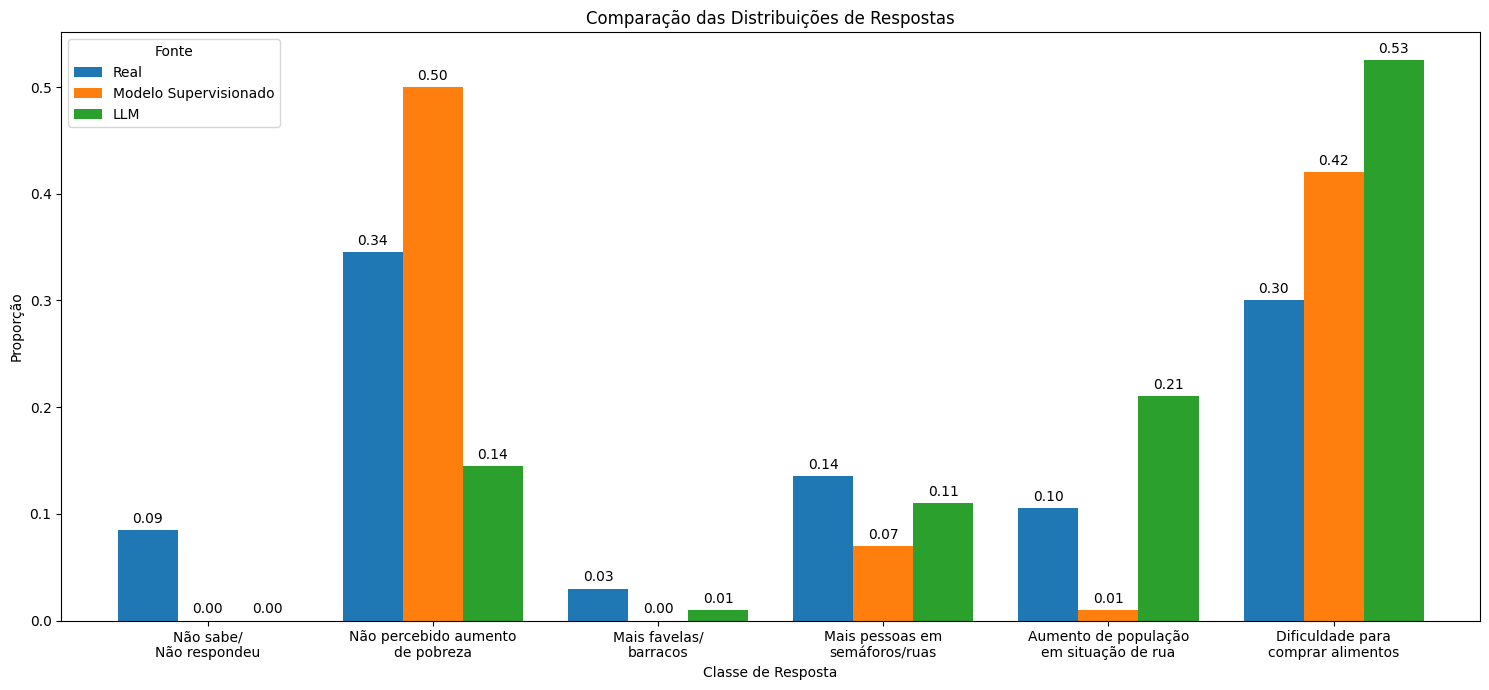


Distância de Jensen-Shannon (JSD) entre Resposta Real e Modelo Supervisionado: 0.2831
Distância de Jensen-Shannon (JSD) entre Resposta Real e LLM: 0.2796
Distância de Jensen-Shannon (JSD) entre Modelo Supervisionado e LLM: 0.3409

Valores de JSD mais próximos de 0 indicam maior similaridade entre as distribuições.


In [ ]:

# 4. Comparação das Distribuições de Respostas (com JSD)
# Nesta etapa, comparamos as distribuições das respostas do modelo supervisionado e do LLM
# em relação às respostas reais. Utilizamos visualizações e a Distância de Jensen-Shannon (JSD)
# para quantificar essas comparações.

if 'df_comparacao' not in locals() or df_comparacao.empty:
    print("Erro: DataFrame 'df_comparacao' não encontrado ou vazio. Execute as etapas anteriores.")
    exit()

if 'all_possible_classes' not in locals() or not all_possible_classes:
    print("Erro: Lista 'all_possible_classes' não encontrada ou vazia. Execute as etapas anteriores.")
    exit()

# Filtrar apenas as linhas onde temos respostas para todos os trêS
# (real, modelo, llm) para uma comparação justa das distribuições
df_comparacao_dist = df_comparacao.dropna(subset=['resposta_real', 'resposta_modelo', 'resposta_llm']).copy()

if df_comparacao_dist.empty:
    print("Nenhuma linha válida para comparação de distribuições após remover NaNs.")
else:
    # Obter distribuições de probabilidade
    # Usamos pd.Series para garantir que value_counts funcione e preenchemos classes faltantes com 0
    dist_real = pd.Series(df_comparacao_dist['resposta_real']).value_counts(normalize=True).reindex(all_possible_classes, fill_value=0)
    dist_modelo = pd.Series(df_comparacao_dist['resposta_modelo']).value_counts(normalize=True).reindex(all_possible_classes, fill_value=0)
    dist_llm = pd.Series(df_comparacao_dist['resposta_llm']).value_counts(normalize=True).reindex(all_possible_classes, fill_value=0)

    # Visualizar as distribuições
    df_dists = pd.DataFrame({
        'Real': dist_real,
        'Modelo Supervisionado': dist_modelo,
        'LLM': dist_llm
    })

    # Novas labels para o eixo X com quebras de linha
    new_x_labels = [
        "Não sabe/\nNão respondeu",
        "Não percebido aumento\nde pobreza",
        "Mais favelas/\nbarracos",
        "Mais pessoas em\nsemáforos/ruas",
        "Aumento de população\nem situação de rua",
        "Dificuldade para\ncomprar alimentos"
    ]

    ax = df_dists.plot(kind='bar', figsize=(15, 7), width=0.8)
    plt.title('Comparação das Distribuições de Respostas')
    plt.ylabel('Proporção')
    plt.xlabel('Classe de Resposta')
    plt.xticks(ticks=range(len(new_x_labels)), labels=new_x_labels, rotation=0, ha='center') # Aplica as novas labels com rotação 0
    plt.legend(title='Fonte')

    # Adicionar rótulos de dados
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

    plt.tight_layout()
    plt.show()

    # Calcular a Distância de Jensen-Shannon (JSD)

    # JSD entre Real e Modelo
    jsd_real_modelo = jensenshannon(dist_real, dist_modelo)
    print(f"\nDistância de Jensen-Shannon (JSD) entre Resposta Real e Modelo Supervisionado: {jsd_real_modelo:.4f}")

    # JSD entre Real e LLM
    jsd_real_llm = jensenshannon(dist_real, dist_llm)
    print(f"Distância de Jensen-Shannon (JSD) entre Resposta Real e LLM: {jsd_real_llm:.4f}")

    # JSD entre Modelo e LLM (opcional, para ver a similaridade entre as predições)
    jsd_modelo_llm = jensenshannon(dist_modelo, dist_llm)
    print(f"Distância de Jensen-Shannon (JSD) entre Modelo Supervisionado e LLM: {jsd_modelo_llm:.4f}")

    print("\nValores de JSD mais próximos de 0 indicam maior similaridade entre as distribuições.")

### Comparativo da Distribuição de Previsões: Modelo Supervisionado vs. LLM (Gráfico de Linhas)

Este gráfico de linhas permite comparar visualmente como as previsões do Modelo Supervisionado e do LLM se distribuem entre as diferentes categorias da variável alvo `p5_desc`.

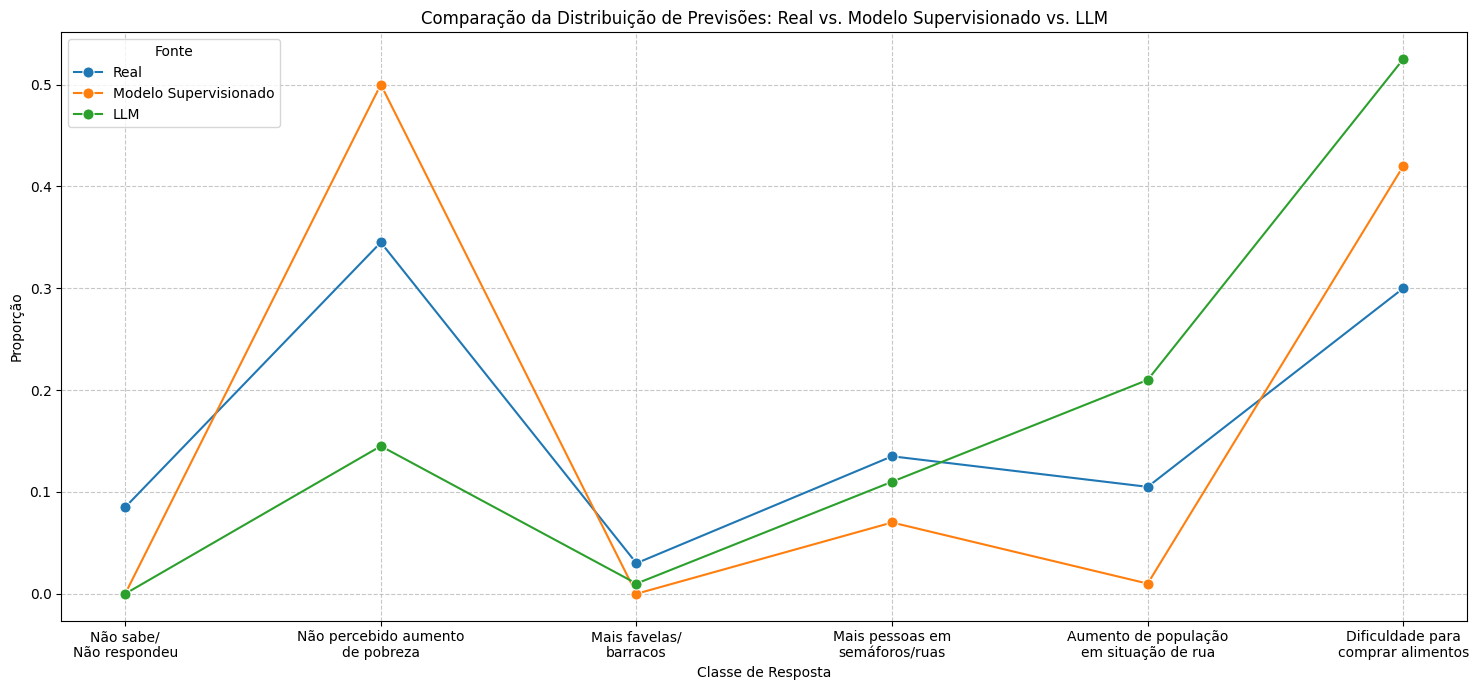

In [ ]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=df_dists[['Real', 'Modelo Supervisionado', 'LLM']], dashes=False, marker='o', markersize=8)
plt.title('Comparação da Distribuição de Previsões: Real vs. Modelo Supervisionado vs. LLM')
plt.xlabel('Classe de Resposta')
plt.ylabel('Proporção')
plt.xticks(ticks=range(len(new_x_labels)), labels=new_x_labels, rotation=0, ha='center')
plt.legend(title='Fonte')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()